<a href="https://colab.research.google.com/github/lena-amzal/image-classifier-cnn/blob/main/Projet_IA_DeepL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1) IMPORT LIBRAIRIES**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#**2) Loading of the dataset**

Cifar10 is a dataset of 50,000 32x32 color training images and 10,000 test images, labeled over 10 categories :

| Classe | Label |
|--------|-------|
| Airplane | 0 |
| Automobile | 1 |
| Bird | 2 |
| Cat | 3 |
| Deer | 4 |
| Dog | 5 |
| Frog | 6 |
| Horse | 7 |
| Ship | 8 |
| Truck | 9 |

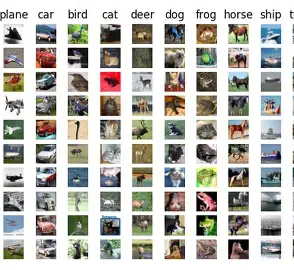

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(y_train)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[[6]
 [9]
 [9]
 ...
 [9]
 [1]
 [1]]


#**3) Preparation of the dataset**

In [ ]:
x_train = x_train.reshape((50000, 32, 32, 3))
x_test  = x_test.reshape((10000, 32, 32, 3))

# Normalisation
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Encoding
y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)

print('  X_train:', x_train.shape, '  y_train:', y_train.shape)
print('  X_test :', x_test.shape,  '  y_test :', y_test.shape)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
  X_train: (50000, 32, 32, 3)   y_train: (50000, 10)
  X_test : (10000, 32, 32, 3)   y_test : (10000, 10)


**CNN**

In [ ]:

model = models.Sequential()

model.add(layers.Input(shape=(32,32,3)))

model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
start_time = time.time()

history_base = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.1)

total_time = time.time() - start_time
print(f"Total training time: {total_time:.2f} seconds")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4408 - loss: 1.5563 - val_accuracy: 0.5474 - val_loss: 1.3145
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.5706 - loss: 1.2167 - val_accuracy: 0.5918 - val_loss: 1.1511
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.6289 - loss: 1.0710 - val_accuracy: 0.6474 - val_loss: 1.0323
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.6567 - loss: 0.9882 - val_accuracy: 0.6538 - val_loss: 0.9876
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.6792 - loss: 0.9287 - val_accuracy: 0.6696 - val_loss: 0.9457
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.6968 - loss: 0.8741 - val_accuracy: 0.6790 - val_loss: 0.9231
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.7129 - loss: 0.8300 - val_accuracy: 0.6814 - val_loss: 0.9226
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.7280 - loss: 0.7861 - 

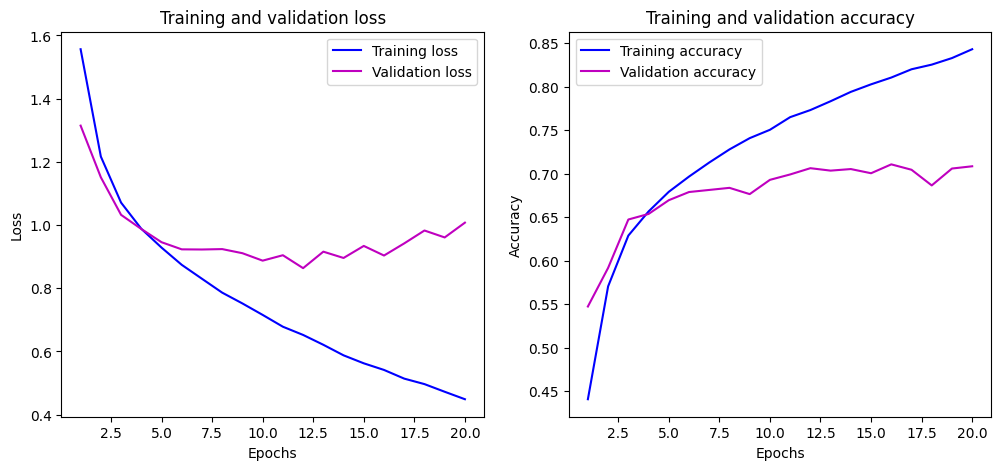

In [ ]:
train_acc = history_base.history['accuracy']
val_acc = history_base.history['val_accuracy']
train_loss = history_base.history['loss']
val_loss = history_base.history['val_loss']

epochs = range(1, len(train_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

### Loss plot ###
axes[0].plot(epochs, train_loss, 'b', label='Training loss')
axes[0].plot(epochs, val_loss, 'm', label='Validation loss')
axes[0].set_title('Training and validation loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

### Accuracy plot ###
axes[1].plot(epochs, train_acc, 'b', label='Training accuracy')
axes[1].plot(epochs, val_acc, 'm', label='Validation accuracy')
axes[1].set_title('Training and validation accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.show()

From epoch 6, the validation loss increases while the training loss continues to decrease, indicating overfitting

In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/") # MODIFY according to YOUR PATH

In [ ]:
model.save('model.keras')

In [ ]:
import pickle

with open('history.pkl', 'wb') as f:
    pickle.dump(history_base.history, f)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
results = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6911 - loss: 1.0916


In [ ]:
import tensorflow as tf
import gc

# Clean the memory
tf.keras.backend.clear_session()
del model
gc.collect()

0

In [ ]:
model_improved = models.Sequential()

model_improved.add(layers.Input(shape=(32,32,3)))

model_improved.add(layers.Conv2D(32, (3, 3), activation='relu'))
model_improved.add(layers.MaxPooling2D((2, 2)))

model_improved.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_improved.add(layers.MaxPooling2D((2, 2)))

model_improved.add(layers.Flatten())
model_improved.add(layers.Dense(64,activation='relu'))

DROPOUT

In [ ]:
model_improved.add(layers.Dropout(0.5))

model_improved.add(layers.Dense(10, activation='softmax'))

model_improved.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

EARLY STOPPING

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


Data augmentation

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

In [ ]:
history_improved = model_improved.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.2904 - loss: 1.9005 - val_accuracy: 0.4542 - val_loss: 1.5216
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.3948 - loss: 1.6370 - val_accuracy: 0.5016 - val_loss: 1.3742
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.4385 - loss: 1.5421 - val_accuracy: 0.5571 - val_loss: 1.2475
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - accuracy: 0.4668 - loss: 1.4738 - val_accuracy: 0.5612 - val_loss: 1.2263
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.4885 - loss: 1.4184 - val_accuracy: 0.5954 - val_loss: 1.1492
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.5008 - loss: 1.3898 - val_accuracy: 0.6111 - val_loss: 1.1310
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 66ms/step - accuracy: 0.5134 - loss: 1.3638 - val_accuracy: 0.6088 - val_loss: 1.1071
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.5217 - loss: 1.3381 - 

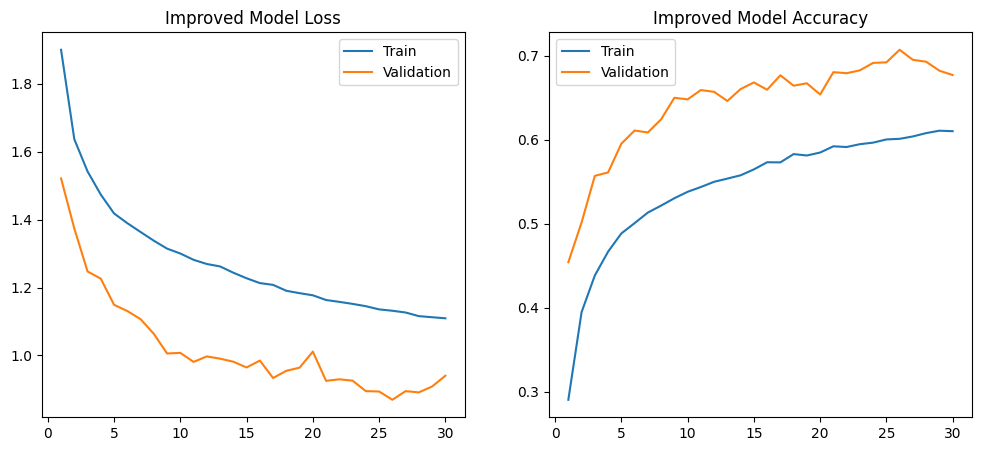

In [ ]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='Train')
    plt.plot(epochs, val_loss, label='Validation')
    plt.title(title + " Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='Train')
    plt.plot(epochs, val_acc, label='Validation')
    plt.title(title + " Accuracy")
    plt.legend()

    plt.show()

plot_history(history_improved, "Improved Model")

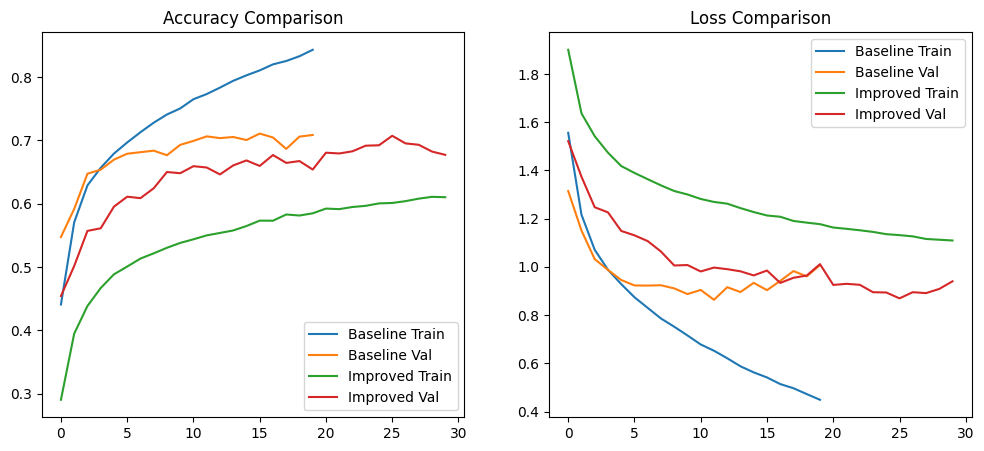

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy comparison
plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Baseline Train')
plt.plot(history_base.history['val_accuracy'], label='Baseline Val')
plt.plot(history_improved.history['accuracy'], label='Improved Train')
plt.plot(history_improved.history['val_accuracy'], label='Improved Val')
plt.title("Accuracy Comparison")
plt.legend()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Baseline Train')
plt.plot(history_base.history['val_loss'], label='Baseline Val')
plt.plot(history_improved.history['loss'], label='Improved Train')
plt.plot(history_improved.history['val_loss'], label='Improved Val')
plt.title("Loss Comparison")
plt.legend()

plt.show()

In [ ]:
results_improved = model_improved.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7073 - loss: 0.8696


In [ ]:
import pandas as pd

df_results = pd.DataFrame({
    "Model": ["Baseline CNN", "Improved CNN"],
    "Accuracy": [results[1], results_improved[1]],
    "Loss": [results[0], results_improved[0]]
})

display(df_results)

,Model,Accuracy,Loss
0,Baseline CNN,0.6911,1.091565
1,Improved CNN,0.7073,0.869552


In [ ]:
model.save("baseline_cnn.keras")

import pickle
with open("history_base.pkl", "wb") as f:
    pickle.dump(history_base.history, f)

NameError: name 'model' is not defined

In [ ]:
model_improved.save("improved_cnn.keras")

with open("history_improved.pkl", "wb") as f:
    pickle.dump(history_improved.history, f)